In [1]:
import pandas as pd
from statsbombpy import sb
from mplsoccer import Sbopen

In [2]:
comp = sb.competitions()

comp.competition_name.unique()

array(['1. Bundesliga', 'African Cup of Nations', 'Champions League',
       'Copa America', 'Copa del Rey', "FA Women's Super League",
       'FIFA U20 World Cup', 'FIFA World Cup', 'Indian Super league',
       'La Liga', 'Liga Profesional', 'Ligue 1', 'Major League Soccer',
       'North American League', 'NWSL', 'Premier League', 'Serie A',
       'UEFA Euro', 'UEFA Europa League', "UEFA Women's Euro",
       "Women's World Cup"], dtype=object)

In [3]:
comp = comp[comp['competition_name'] == 'UEFA Euro']

comp

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
68,55,282,Europe,UEFA Euro,male,False,True,2024,2024-07-15T15:48:50.315500,2024-07-15T15:52:24.778809,2024-07-15T15:52:24.778809,2024-07-15T15:48:50.315500
69,55,43,Europe,UEFA Euro,male,False,True,2020,2024-04-16T12:44:40.558402,2024-04-16T12:47:18.505110,2024-04-16T12:47:18.505110,2024-04-16T12:44:40.558402


In [4]:
matches = sb.matches(competition_id=55 ,season_id=282)
matches

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,3942819,2024-07-10,22:00:00.000,Europe - UEFA Euro,2024,Netherlands,England,1,2,available,...,2024-07-15T07:57:36.684453,6,Semi-finals,Signal-Iduna-Park,Felix Zwayer,Ronald Koeman,Gareth Southgate,1.1.0,2,2
1,3943043,2024-07-14,22:00:00.000,Europe - UEFA Euro,2024,Spain,England,2,1,available,...,2024-07-15T15:52:24.778809,7,Final,Olympiastadion Berlin,François Letexier,Luis de la Fuente Castillo,Gareth Southgate,1.1.0,2,2
2,3942752,2024-07-09,22:00:00.000,Europe - UEFA Euro,2024,Spain,France,2,1,available,...,2024-07-10T13:01:26.597509,6,Semi-finals,Allianz Arena,Slavko Vinčić,Luis de la Fuente Castillo,Didier Deschamps,1.1.0,2,2
3,3942382,2024-07-06,22:00:00.000,Europe - UEFA Euro,2024,Netherlands,Turkey,2,1,available,...,2024-07-10T06:56:35.146850,5,Quarter-finals,Olympiastadion Berlin,Clément Turpin,Ronald Koeman,Vincenzo Montella,1.1.0,2,2
4,3942349,2024-07-05,22:00:00.000,Europe - UEFA Euro,2024,Portugal,France,0,0,available,...,2024-07-12T02:00:16.871522,5,Quarter-finals,Volksparkstadion,Michael Oliver,Roberto Martínez Montoliú,Didier Deschamps,1.1.0,2,2
5,3930180,2024-06-25,19:00:00.000,Europe - UEFA Euro,2024,Netherlands,Austria,2,3,available,...,2024-07-11T13:25:37.289456,3,Group Stage,Olympiastadion Berlin,Ivan Kružliak,Ronald Koeman,Ralf Rangnick,1.1.0,2,2
6,3930171,2024-06-20,19:00:00.000,Europe - UEFA Euro,2024,Denmark,England,1,1,available,...,2024-07-12T05:19:44.572914,2,Group Stage,Deutsche Bank Park,Artur Manuel Ribeiro Soares Dias,Kasper Hjulmand,Gareth Southgate,1.1.0,2,2
7,3942227,2024-07-06,19:00:00.000,Europe - UEFA Euro,2024,England,Switzerland,1,1,available,...,2024-07-14T15:57:51.414762,5,Quarter-finals,Merkur Spiel-Arena,Daniele Orsato,Gareth Southgate,Murat Yakin,1.1.0,2,2
8,3942226,2024-07-05,19:00:00.000,Europe - UEFA Euro,2024,Spain,Germany,2,1,available,...,2024-07-13T03:52:43.383929,5,Quarter-finals,MHPArena,Anthony Taylor,Luis de la Fuente Castillo,Julian Nagelsmann,1.1.0,2,2
9,3938645,2024-06-26,19:00:00.000,Europe - UEFA Euro,2024,Ukraine,Belgium,0,0,available,...,2024-07-11T16:17:18.090189,3,Group Stage,MHPArena,Anthony Taylor,Sergiy Rebrov,Domenico Tedesco,1.1.0,2,2


In [5]:
spainMatches = matches.match_id[matches['home_team'] == 'Spain']
spainMatches

1     3943043
2     3942752
8     3942226
15    3941018
23    3930172
48    3930160
Name: match_id, dtype: int64

In [6]:
import numpy as np

spainMatches = np.array(spainMatches)

spainMatches

array([3943043, 3942752, 3942226, 3941018, 3930172, 3930160])

In [7]:
np.append(spainMatches,matches.match_id[matches['away_team'] == 'Spain'])

array([3943043, 3942752, 3942226, 3941018, 3930172, 3930160, 3930179])

In [8]:
parser = Sbopen()

match = sb.events(match_id= 3930160)

df,refered,freeze,tactics = parser.event(3930160)

In [9]:
df2 = df[['outcome_name','minute']].dropna(axis=0)

In [10]:
df2[df2['outcome_name']=='Goal']

,outcome_name,minute
1241,Goal,28
1321,Goal,31
1816,Goal,46


In [11]:
df3 = pd.DataFrame()
for i in spainMatches : 
    match = sb.events(match_id= i)
    df,refered,freeze,tactics = parser.event(i)
    df2 = df[['outcome_name','minute']].dropna(axis=0)
    df3 = pd.concat([df3,df2[df2['outcome_name']=='Goal']])


df3

,outcome_name,minute
1775,Goal,46
2709,Goal,72
3219,Goal,85
373,Goal,8
764,Goal,20
881,Goal,24
1867,Goal,51
3197,Goal,88
4343,Goal,118
1700,Goal,38


In [12]:
print(np.mean(df3.minute))

53.8125


In [13]:
first = sec = third = fourth = fifth = last = additional = 0

for i in df3['minute']:
    if 0 <= i < 15:
        first += 1
    elif 15 <= i < 30:
        sec += 1
    elif 30 <= i < 45:
        third += 1
    elif 45 <= i < 60:
        fourth += 1
    elif 60 <= i < 75:
        fifth += 1
    elif 75 <= i < 90:
        last += 1
    else:
        additional += 1


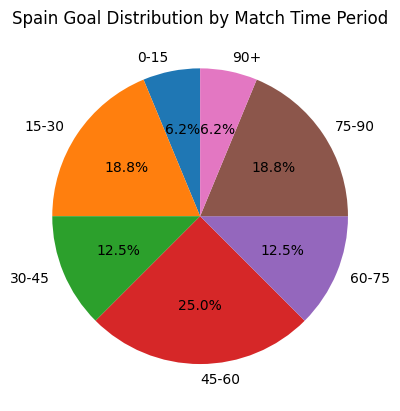

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

labels = ['0-15', '15-30', '30-45', '45-60', '60-75', '75-90', '90+']
values = [first, sec, third, fourth, fifth, last, additional]

ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
ax.set_title('Spain Goal Distribution by Match Time Period')

plt.show()